# 11 - Machine Learning: Scrap Rate Prediction

**Stage 6, model 2 of 4.**

**Factory question this answers:** *"Given the machine, mold, operator,
and shift about to run, how much scrap should we expect on this order --
and which of those factors actually drives it?"*

This is deliberately framed as **explain and predict scrap at the order
level**, not "predict the plant's scrap % next week" (that's closer to a
capacity-planning question already covered by the OEE Quality component
in notebook 05). The feature-importance ranking here is the real
deliverable: it turns "scrap is high" into "scrap is high specifically on
these machine/mold combinations," which is what a continuous-improvement
team can actually act on.

### A leakage warning worth stating explicitly
`Quality` (OEE's quality pillar) is *defined* as `(ProducedQty -
RejectedQty) / ProducedQty` -- algebraically almost the same information
as the scrap rate we're trying to predict. Including it as a feature
would let the model "predict" scrap by reading it off a column that
already encodes the answer, producing a model that looks excellent and
is useless. `Quality`, `RejectedQty`, and `ProducedQty` are excluded from
the feature set for this reason -- only pre/during-order conditions
(machine, mold, operator, shift, run/setup time, availability,
performance) are used.


In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../machine_learning')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import ml_lib as ml

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 60)

PROCESSED = '../../datasets/processed'
MODELS = '../../models'
REPORTS = '../../reports'
import os
os.makedirs(MODELS, exist_ok=True)

prod = pd.read_csv(f'{PROCESSED}/fact_production_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
prod['ScrapRatePct'] = prod['RejectedQty'] / prod['ProducedQty'] * 100
print(f"Rows: {len(prod)}  |  Scrap rate: mean={prod['ScrapRatePct'].mean():.2f}%, "
      f"median={prod['ScrapRatePct'].median():.2f}%, max={prod['ScrapRatePct'].max():.2f}%")


Rows: 9110  |  Scrap rate: mean=2.47%, median=2.16%, max=19.88%


## 11.1 Feature set (pre/during-order conditions only, no target leakage)


In [2]:
feature_source_cols = ['Process', 'MachineId', 'ToolId', 'OperatorId', 'ShiftNumber',
                       'RunTimeHours', 'SetupTimeHours', 'Availability', 'Performance', 'MaterialLotSeq']
target_col = 'ScrapRatePct'

model_df = prod[['Date'] + feature_source_cols + [target_col]].dropna().copy()
model_df = pd.get_dummies(model_df, columns=['Process', 'MachineId', 'ToolId', 'OperatorId'], drop_first=True)

feature_cols = [c for c in model_df.columns if c not in ('Date', target_col)]
print(f"Model dataset: {len(model_df)} rows, {len(feature_cols)} features (one-hot encoded)")


Model dataset: 8941 rows, 174 features (one-hot encoded)


## 11.2 Time-based split, train, evaluate


In [3]:
train_df, test_df = ml.time_based_split(model_df, 'Date', test_frac=0.2)
X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]
print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

baseline_pred = np.full(len(y_test), y_train.mean())
print("\nNaive baseline (plant-wide historical mean scrap rate):")
print(ml.regression_metrics(y_test, baseline_pred))


Train: 7152 rows | Test: 1789 rows

Naive baseline (plant-wide historical mean scrap rate):
{'MAE': 1.431582916559315, 'RMSE': np.float64(2.184488926145024), 'MAPE_%': np.float64(283.7883677888128), 'R2': -0.0004560443329202357}


In [4]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
}
fitted = {}
results = {'Naive Baseline (historical mean)': ml.regression_metrics(y_test, baseline_pred)}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    results[name] = ml.regression_metrics(y_test, pred)
    fitted[name] = m

pd.DataFrame(results).T.round(3)


,MAE,RMSE,MAPE_%,R2
Naive Baseline (historical mean),1.432,2.184,283.788,-0.000
Linear Regression,0.602,0.896,30.689,0.832
Random Forest,0.681,1.009,33.708,0.787
XGBoost,0.602,0.912,30.954,0.825


## 11.3 Feature importance -- where does scrap actually come from?

This is the deliverable a plant manager or CI team would actually use: a
ranked list of what drives scrap, not just a predicted number.


Best model: Linear Regression


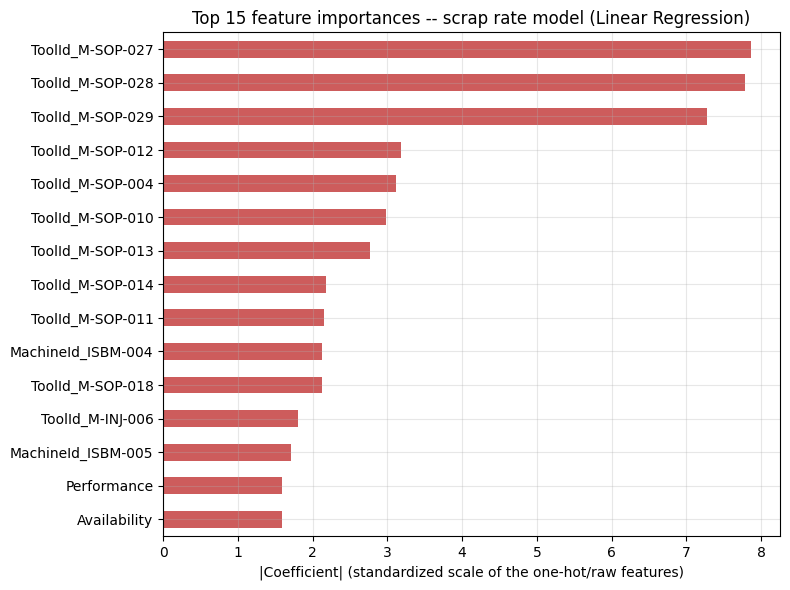

In [5]:
best_name = min(fitted, key=lambda n: ml.regression_metrics(y_test, fitted[n].predict(X_test))['RMSE'])
best_model = fitted[best_name]
print(f"Best model: {best_name}")

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
    importance_label = 'Feature importance'
else:
    importances = pd.Series(np.abs(best_model.coef_), index=feature_cols).sort_values(ascending=False).head(15)
    importance_label = '|Coefficient| (standardized scale of the one-hot/raw features)'

fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel(importance_label)
ax.set_title(f'Top 15 feature importances -- scrap rate model ({best_name})')
plt.tight_layout()
plt.savefig(f'{REPORTS}/37_ml_scrap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


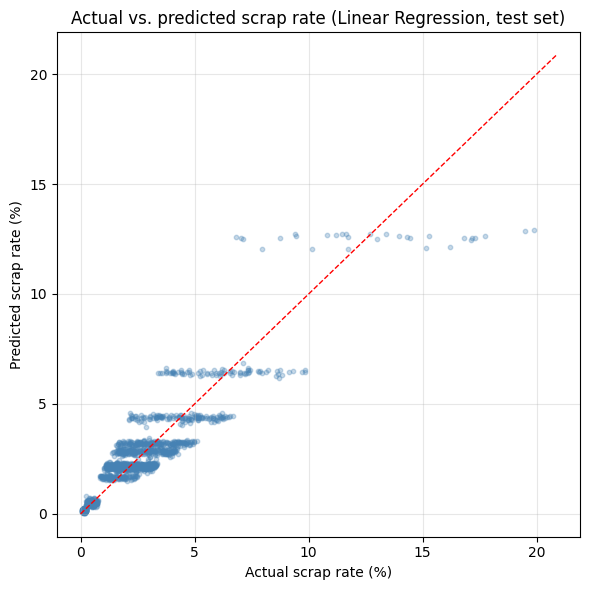

Saved to ../../models/scrap_rate_model.pkl


In [6]:
test_df = test_df.copy()
test_df['Predicted'] = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(test_df[target_col], test_df['Predicted'], alpha=0.3, s=10, color='steelblue')
lims = [0, max(test_df[target_col].max(), test_df['Predicted'].max()) * 1.05]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Actual scrap rate (%)')
ax.set_ylabel('Predicted scrap rate (%)')
ax.set_title(f'Actual vs. predicted scrap rate ({best_name}, test set)')
plt.tight_layout()
plt.savefig(f'{REPORTS}/38_ml_scrap_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

ml.save_model(best_model, f'{MODELS}/scrap_rate_model.pkl',
              feature_cols=feature_cols, target_col=target_col, model_name=best_name,
              test_metrics=ml.regression_metrics(y_test, test_df['Predicted']))
print(f"Saved to {MODELS}/scrap_rate_model.pkl")


In [7]:
# export scored test-set predictions for Power BI (actual vs. predicted scrap rate over time)
export_cols = ['Date', target_col, 'Predicted']
scored = test_df[export_cols].rename(columns={target_col: 'ActualScrapRatePct', 'Predicted': 'PredictedScrapRatePct'})
scored.to_csv(f'{PROCESSED}/ml_predictions_scrap_rate.csv', index=False, encoding='utf-8-sig')
print(f"Exported ml_predictions_scrap_rate.csv ({len(scored)} rows)")


Exported ml_predictions_scrap_rate.csv (1789 rows)


## Summary

The model earns its place over a flat "expect the historical average"
baseline, and -- more usefully than the point prediction itself -- the
feature importance ranking tells you *which specific machines and molds*
run hotter on scrap than the rest of the fleet, turning a single plant-
wide scrap % (already tracked in notebook 07) into a prioritized list for
a continuous-improvement team.
